<font size="5">Section 2: non linear models</font>

# Housekeeping

## import libraries

Pandas for data management, statsmodels, numpy and sklearn for analysis, matplotlib for visualization. Other libraries as needed for specific tasks (e.g. semopy for SEM). Remember to use the bash terminal or the enviroment manager to add libraries.

## read data

Read data files using pandas as noted below. We can clean and organize data in many ways (for example, using the **dropna** command over a dataset).

## describe data

There are many was to analyze data and do descriptive statistics. A good command to start is ***head***, to describe a section of the data.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
from scipy.stats import nbinom
import seaborn as sns
from statsmodels.iolib.summary2 import summary_col

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [2]:
# higher ed data
demre = pd.read_csv('../data/Adm2024.csv', delimiter=";", decimal=',')
demre.dropna(inplace=True)
VIAC = [1,2,3,4]
TIPO = ["REGULAR", "BEA", "PACE", "+MC"]
demre['TIPO'] = demre['VIA'].replace(VIAC, TIPO)
demre["PRA"] = (demre["PREFERENCIA"]== 1).astype(int)
demre.dtypes

ID_aux             object
CODIGO_UNIV         int64
CODIGO              int64
VIA                 int64
PREFERENCIA         int64
PTJE_POND         float64
TIPO_MATRICULA      int64
TIPO               object
PRA                 int64
dtype: object

In [3]:
demre.reset_index(drop=True, inplace=True)
demre= demre[demre['PTJE_POND'] != 0]
demre.head()

,ID_aux,CODIGO_UNIV,CODIGO,VIA,PREFERENCIA,PTJE_POND,TIPO_MATRICULA,TIPO,PRA
0,id_690126976014,51,51111,1,1,709.90,1,REGULAR,1
1,id_831408370144,18,18075,1,1,713.45,1,REGULAR,1
2,id_752607579265,44,44049,1,1,876.10,1,REGULAR,1
3,id_772307770236,21,21043,1,1,643.30,2,REGULAR,1
4,id_481904877199,41,41067,1,1,638.70,1,REGULAR,1


<Axes: xlabel='PTJE_POND', ylabel='Density'>

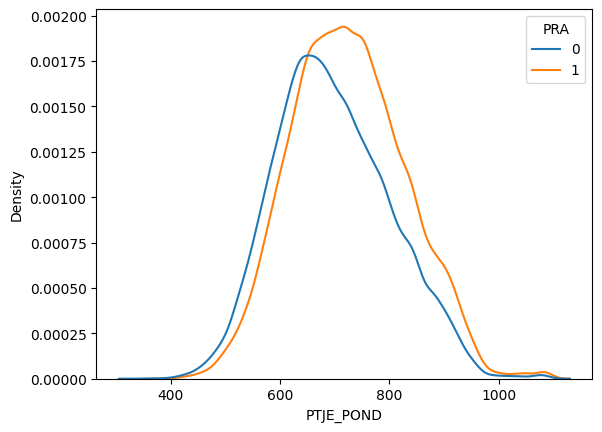

In [4]:
sns.kdeplot(data=demre, x="PTJE_POND", hue="PRA")

### OLS

We can use statsmodels to estimate a simple OLS regression (linear probability model). 

In [5]:
model = smf.ols("PRA ~ PTJE_POND*C(VIA) +C(CODIGO_UNIV, Treatment(13))", data=demre).fit(cov_type='HC1')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    PRA   R-squared:                       0.085
Model:                            OLS   Adj. R-squared:                  0.085
Method:                 Least Squares   F-statistic:                     232.8
Date:                Tue, 31 Mar 2026   Prob (F-statistic):               0.00
Time:                        11:48:31   Log-Likelihood:                -78323.
No. Observations:              115353   AIC:                         1.568e+05
Df Residuals:                  115301   BIC:                         1.573e+05
Df Model:                          51                                         
Covariance Type:                  HC1                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

### Probit



In [6]:
probit_model = smf.probit("PRA ~ PTJE_POND*C(TIPO, Treatment(reference='REGULAR'))", data=demre).fit(cov_type='HC1')
print(probit_model.summary())

mfx = probit_model.get_margeff()
print(mfx.summary())

Optimization terminated successfully.
         Current function value: 0.681557
         Iterations 4
                          Probit Regression Results                           
Dep. Variable:                    PRA   No. Observations:               115353
Model:                         Probit   Df Residuals:                   115345
Method:                           MLE   Df Model:                            7
Date:                Tue, 31 Mar 2026   Pseudo R-squ.:                 0.01355
Time:                        11:48:31   Log-Likelihood:                -78620.
converged:                       True   LL-Null:                       -79700.
Covariance Type:                  HC1   LLR p-value:                     0.000
                                                                coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------
Intercept     

### Logit

In [7]:
logit_model = smf.logit("PRA ~ PTJE_POND*C(TIPO, Treatment(reference='REGULAR'))", data=demre).fit()
print(logit_model.summary())

mfx = logit_model.get_margeff()
print(mfx.summary())

Optimization terminated successfully.
         Current function value: 0.681547
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:                    PRA   No. Observations:               115353
Model:                          Logit   Df Residuals:                   115345
Method:                           MLE   Df Model:                            7
Date:                Tue, 31 Mar 2026   Pseudo R-squ.:                 0.01357
Time:                        11:48:32   Log-Likelihood:                -78618.
converged:                       True   LL-Null:                       -79700.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------
Intercept     

### Poisson

(array([84375., 18629.,  6147.,  2695.,  1394.,   869.,   531.,   341.,
          230.,   142.]),
 array([ 1. ,  2.9,  4.8,  6.7,  8.6, 10.5, 12.4, 14.3, 16.2, 18.1, 20. ]),
 <BarContainer object of 10 artists>)

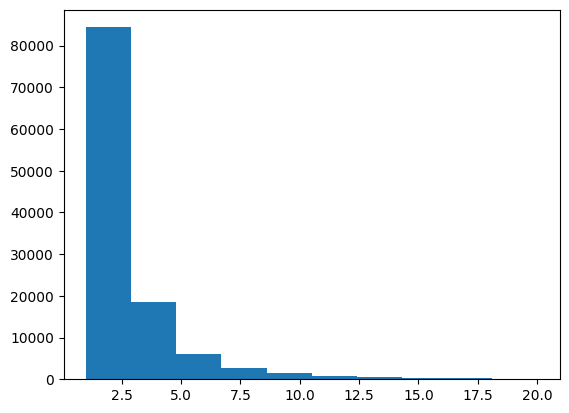

In [8]:
plt.hist(demre.PREFERENCIA)

In [9]:
poisson = smf.poisson("PREFERENCIA ~ PTJE_POND*C(TIPO, Treatment(reference='REGULAR')) + C(CODIGO_UNIV)", data=demre).fit()
print(poisson.summary())

Optimization terminated successfully.
         Current function value: 1.963580
         Iterations 8
                          Poisson Regression Results                          
Dep. Variable:            PREFERENCIA   No. Observations:               115353
Model:                        Poisson   Df Residuals:                   115301
Method:                           MLE   Df Model:                           51
Date:                Tue, 31 Mar 2026   Pseudo R-squ.:                 0.02979
Time:                        11:48:34   Log-Likelihood:            -2.2650e+05
converged:                       True   LL-Null:                   -2.3346e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------
Intercept     

In [10]:
demre['ppredictions'] = poisson.predict(demre).astype(float)
print(demre.ppredictions)

0         2.825263
1         1.587058
2         2.040361
3         2.491098
4         2.636393
            ...   
118354    1.818845
118355    2.277479
118356    2.464773
118357    1.829443
118358    2.749922
Name: ppredictions, Length: 115353, dtype: float64


### Negative Binomial

In [11]:
nbin = smf.negativebinomial("PREFERENCIA ~ PTJE_POND*C(TIPO, Treatment(reference='REGULAR')) + C(CODIGO_UNIV)", data=demre).fit()
print(nbin.summary())

         Current function value: 1.859915
         Iterations: 35
         Function evaluations: 44
         Gradient evaluations: 44
                     NegativeBinomial Regression Results                      
Dep. Variable:            PREFERENCIA   No. Observations:               115353
Model:               NegativeBinomial   Df Residuals:                   115301
Method:                           MLE   Df Model:                           51
Date:                Tue, 31 Mar 2026   Pseudo R-squ.:                 0.01968
Time:                        11:48:41   Log-Likelihood:            -2.1455e+05
converged:                      False   LL-Null:                   -2.1885e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                                coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------

In [12]:
demre['predictions'] = nbin.predict(demre).astype(float)
print(demre.predictions)

0         2.829990
1         1.583185
2         2.044518
3         2.493258
4         2.638288
            ...   
118354    1.816810
118355    2.274879
118356    2.469915
118357    1.833747
118358    2.749545
Name: predictions, Length: 115353, dtype: float64


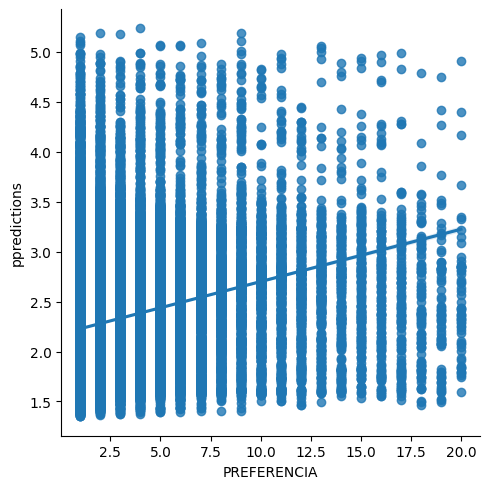

In [13]:
sns.lmplot(x='PREFERENCIA', y='ppredictions', data=demre)

In [14]:
demre['sres']=(demre['PREFERENCIA']-demre['ppredictions'])**2
demre['sres'].sum()/115345

np.float64(5.136694199325585)

### Test overdispersion

A simple test for overdispersion can be determined with the results of the Poisson model, using the ratio of Pearson chi2 / Df Residuals. A value larger than 1 indicates overdispersion.

The Negative Binomial model estimated above jointly with $\alpha$. In some applications we need to determine the appropiate value of $\alpha$, so you can estimate a simple regression using the output of the Poisson model:

1. Construct the following variable aux=$[(y-\lambda)^2-\lambda]/\lambda$
2. Regress the variable aux with $\lambda$ as the only explanatory variable (no constant)
3. The estimated value is an appropiate guess for $\alpha$


In [ ]:
aux=((demre['PREFERENCIA']-demre['ppredictions'])**2-demre['ppredictions'])/demre['ppredictions']
auxr=sm.OLS(aux,demre['ppredictions']).fit()
print(auxr.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.017
Model:                            OLS   Adj. R-squared (uncentered):              0.017
Method:                 Least Squares   F-statistic:                              1966.
Date:                Tue, 31 Mar 2026   Prob (F-statistic):                        0.00
Time:                        11:52:36   Log-Likelihood:                     -4.2004e+05
No. Observations:              115353   AIC:                                  8.401e+05
Df Residuals:                  115352   BIC:                                  8.401e+05
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

<font size="3">**Tarea 1 2026**</font>

<u> *Instrucciones* </u>

Su notebook con las respuestas a la tarea se deben entregar a mas tardar el dia 20/04/26 hasta las 23:59, subiendolo al repositorio en la carpeta tareas/2026 mediante un *pull request* desde su fork. 

Es importante considerar que el código debe poder ejecutarse en cualquier computadora con la data original del repositorio. Recordar la convencion para el nombre de archivo ademas de incluir en su documento titulos y encabezados por seccion. La data a utilizar es **student_productivity.csv**.

Las variables tienen la siguiente descripcion:

- student_id: Identificador único del estudiante.
- age: Edad del estudiante en años.
- gender: Género informado.
- academic_level: Nivel académico actual del estudiante.
- study_hours: Horas totales de estudio diario (incluye estudio en horario de clases y autoestudio).
- self_study_hours: Horas de estudio autónomo fuera de clases.
- online_classes_hours: Horas de clases online (Zoom, Teams, etc).
- social_media_hours: Horas diarias en redes sociales.
- gaming_hours: Horas diarias de videojuegos.
- screen_time_hours: Tiempo total frente a pantallas en horas.
- sleep_hours: Horas de sueño diarias.
- exercise_minutes: Minutos de ejercicio físico diario.
- caffeine_intake_mg: Miligramos de cafeína consumidos de forma diaria.
- part_time_job: Indica si es que el estudiante tiene un trabajo de medio tiempo o no.
- upcoming_deadline: Indica si es que el estudiante tiene alguna entrega o examen próximamente.
- internet_quality: Calidad de la conexión a internet disponible para estudiar.
- drug_use: Indicador de consumo de sustancias recreativas.
- mental_health_score: Puntuación de salud mental del estudiante autoreportada.
- focus_index: Indice que nos indica el nivel de concentración del estudiante.
- burnout_level: Nivel de agotamiento del estudiante.
- productivity_score: Nivel de productividad del estudiante.
- exam_score: Puntuación en el examen final (1.0 indica un estudiante que no rindio el examen).

<u> Preguntas (todas tienen el mismo puntaje): </u> 

1. Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario. Genere una variable binaria para indicar quienes dieron el test. Justifique su proceso.


2. Ejecute un modelo de probabilidad lineal (*MCO*) que permita explicar la probabilidad de que un alumno rinda el examen, a partir de las informacion disponible. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

3. Ejecute un modelo *probit* para responder a la pregunta 2. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

4. Ejecute un modelo *logit*  para responder a la pregunta 2. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

5. Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

6. Use un modelo Poisson para explicar la nota del examen, entre aquellos alumnos que lo rindieron. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

7. Determine si existe sobre dispersion en la data y posible valor optimo de alpha para un modelo Binomial Negativa.

8. Usando la informacion anterior, ejecute un modelo Binomial Negativa para responder a la pregunta 6. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado. 

9. Comente los resultados obtenidos en 6, 7 y 8. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?